<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/XAI_XGBoost_SHAP_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q xgboost scikit-survival shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 14.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 145.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

from scipy.stats import spearmanr

from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

print("XGBoost:", xgb.__version__)
print("SHAP:", shap.__version__)

Mounted at /content/drive
XGBoost: 3.4.1
SHAP: 0.52.0


In [3]:
BASE_DIR = Path(
    "/content/drive/MyDrive/Uniklinikum Würzburg/AML/"
    "Output Files 2/combined_survival_model_ready_wout_protocol/"
)

TRAIN_PATH = BASE_DIR / "combined_train_survival_model_ready.csv"
VALIDATION_PATH = BASE_DIR / "combined_validation_survival_model_ready.csv"
TEST_PATH = BASE_DIR / "combined_test_survival_model_ready.csv"

XAI_OUTPUT_DIR = BASE_DIR / "xgboost_shap_xai"
XAI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (620, 68)
Validation: (177, 68)
Test: (89, 68)


In [4]:
DURATION_COL = "OS_DAYS"
EVENT_COL = "OS_EVENT"

ID_COLS = [
    "PATIENT_ID",
    "SAMPLE_ID"
]

EXCLUDE_COLS = ID_COLS + [
    DURATION_COL,
    EVENT_COL
]

FEATURE_COLS = [
    col
    for col in train_df.columns
    if col not in EXCLUDE_COLS
]

X_train = train_df[FEATURE_COLS].astype(float)
X_val = val_df[FEATURE_COLS].astype(float)
X_test = test_df[FEATURE_COLS].astype(float)

durations_train = train_df[DURATION_COL].astype(float).values
events_train = train_df[EVENT_COL].astype(int).values

durations_val = val_df[DURATION_COL].astype(float).values
events_val = val_df[EVENT_COL].astype(int).values

durations_test = test_df[DURATION_COL].astype(float).values
events_test = test_df[EVENT_COL].astype(int).values

# XGBoost survival:Cox labels:
# event -> positive time
# censored -> negative time

y_train_xgb = np.where(
    events_train == 1,
    durations_train,
    -durations_train
)

y_val_xgb = np.where(
    events_val == 1,
    durations_val,
    -durations_val
)

y_test_xgb = np.where(
    events_test == 1,
    durations_test,
    -durations_test
)

print("Number of features:", len(FEATURE_COLS))

Number of features: 64


In [5]:
dtrain = xgb.DMatrix(
    X_train,
    label=y_train_xgb,
    feature_names=FEATURE_COLS
)

dval = xgb.DMatrix(
    X_val,
    label=y_val_xgb,
    feature_names=FEATURE_COLS
)

dtest = xgb.DMatrix(
    X_test,
    label=y_test_xgb,
    feature_names=FEATURE_COLS
)

In [6]:
BEST_PARAMS = {
    "objective": "survival:cox",
    "eval_metric": "cox-nloglik",

    "tree_method": "hist",

    "max_depth": 5,
    "eta": 0.03,
    "min_child_weight": 3,

    "subsample": 0.70,
    "colsample_bytree": 0.70,

    "lambda": 5.0,
    "alpha": 0.10,

    "seed": 42,
    "verbosity": 0
}

In [7]:
evals_result = {}

xgb_model = xgb.train(
    params=BEST_PARAMS,

    dtrain=dtrain,

    num_boost_round=2000,

    evals=[
        (dtrain, "train"),
        (dval, "validation")
    ],

    early_stopping_rounds=50,

    evals_result=evals_result,

    verbose_eval=False
)

BEST_ITERATION = xgb_model.best_iteration + 1

print("Best number of trees:", BEST_ITERATION)

Best number of trees: 131


In [8]:
def calculate_cindex(
    events,
    durations,
    risk_scores
):
    return concordance_index_censored(
        events.astype(bool),
        durations,
        risk_scores
    )[0]

In [9]:
train_risk = xgb_model.predict(
    dtrain,
    iteration_range=(0, BEST_ITERATION)
)

val_risk = xgb_model.predict(
    dval,
    iteration_range=(0, BEST_ITERATION)
)

test_risk = xgb_model.predict(
    dtest,
    iteration_range=(0, BEST_ITERATION)
)

train_cindex = calculate_cindex(
    events_train,
    durations_train,
    train_risk
)

val_cindex = calculate_cindex(
    events_val,
    durations_val,
    val_risk
)

test_cindex = calculate_cindex(
    events_test,
    durations_test,
    test_risk
)

print(f"Train C-index:      {train_cindex:.3f}")
print(f"Validation C-index: {val_cindex:.3f}")
print(f"Test C-index:       {test_cindex:.3f}")

Train C-index:      0.842
Validation C-index: 0.692
Test C-index:       0.661


In [10]:
explainer = shap.TreeExplainer(
    xgb_model
)

print("SHAP TreeExplainer created.")

SHAP TreeExplainer created.


In [11]:
shap_values_val = explainer(
    X_val
)

print(
    "SHAP matrix shape:",
    shap_values_val.values.shape
)

SHAP matrix shape: (177, 64)


In [12]:
mean_abs_shap_val = np.abs(
    shap_values_val.values
).mean(axis=0)

shap_importance_val = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Mean_Abs_SHAP": mean_abs_shap_val
})

shap_importance_val = (
    shap_importance_val
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 SHAP features:")
display(
    shap_importance_val.head(20)
)

Top 20 SHAP features:


,Feature,Mean_Abs_SHAP
0,RISK_GROUP_CLEAN_Low,0.355739
1,AGE,0.125421
2,PERIPHERAL_BLASTS_PERCENTAGE,0.108957
3,RACE_Black or African American,0.104308
4,WBC_LOG1P,0.101450
5,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.091020
6,RACE_White,0.081084
7,ETHNICITY_Hispanic or Latino,0.070893
8,FAB_M5,0.066695
9,PRIMARY_CYTOGENETIC_CODE_Other,0.042021


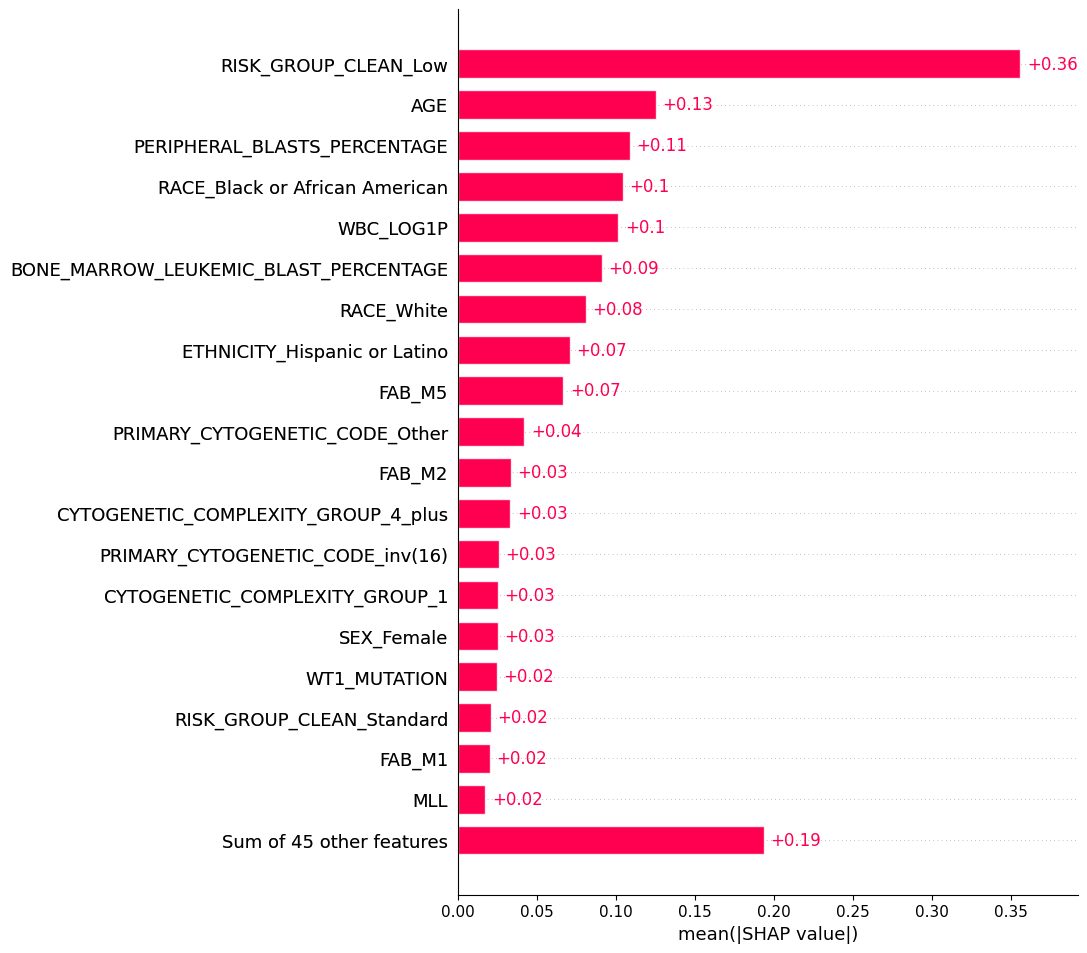

In [13]:
shap.plots.bar(
    shap_values_val,
    max_display=20
)

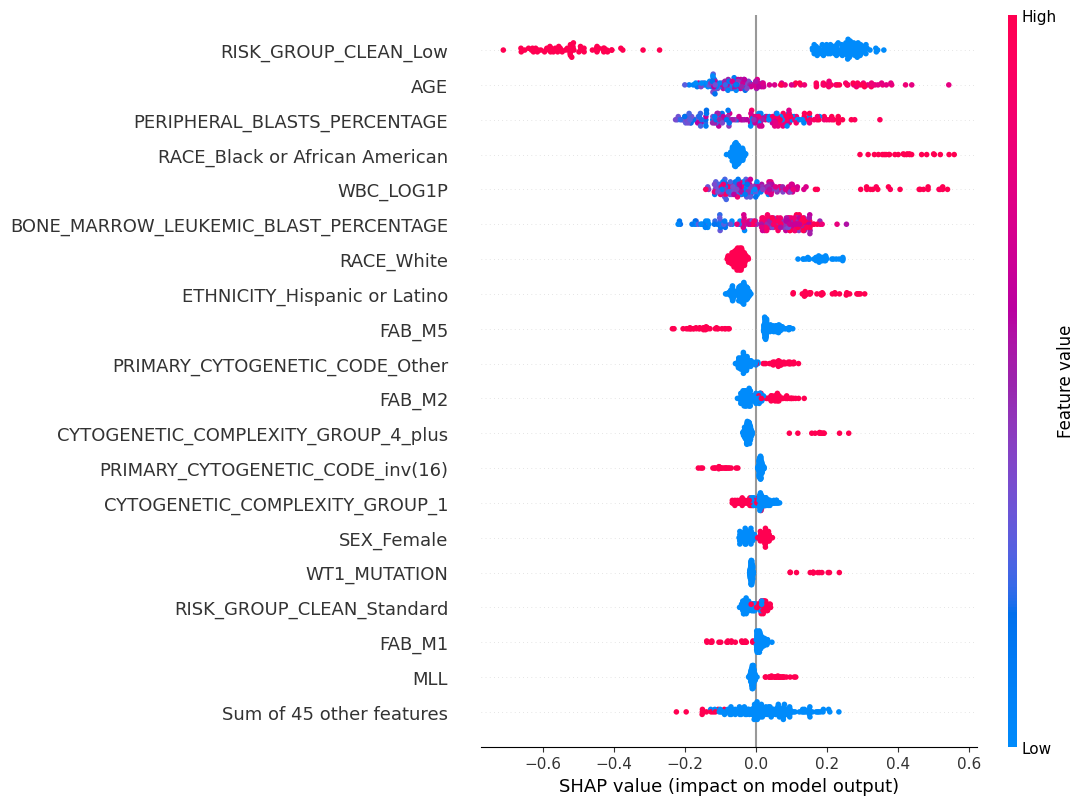

In [14]:
shap.plots.beeswarm(
    shap_values_val,
    max_display=20
)

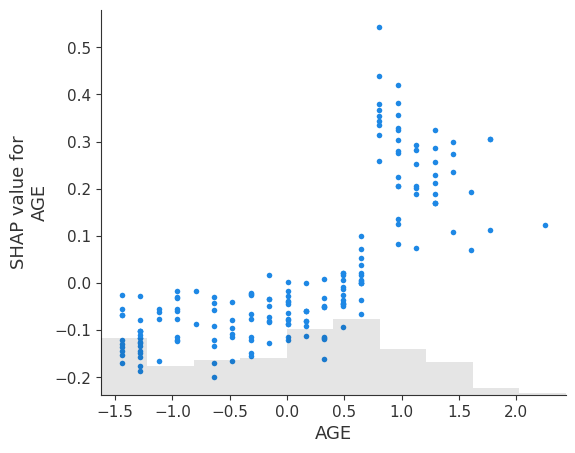

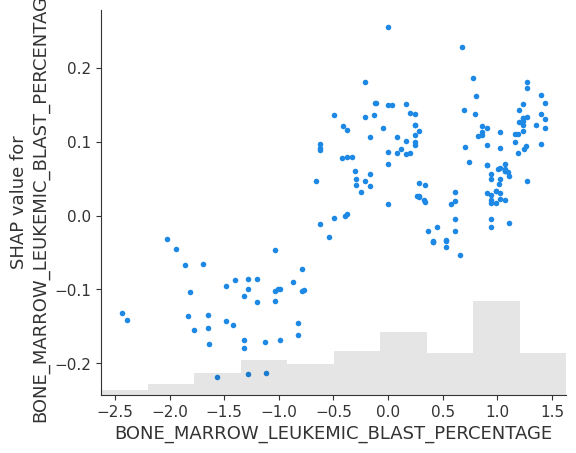

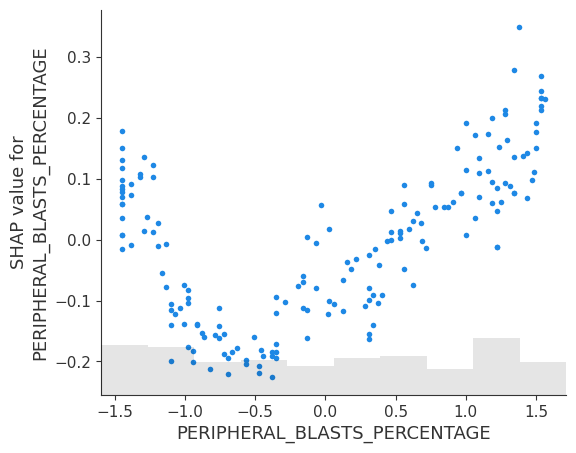

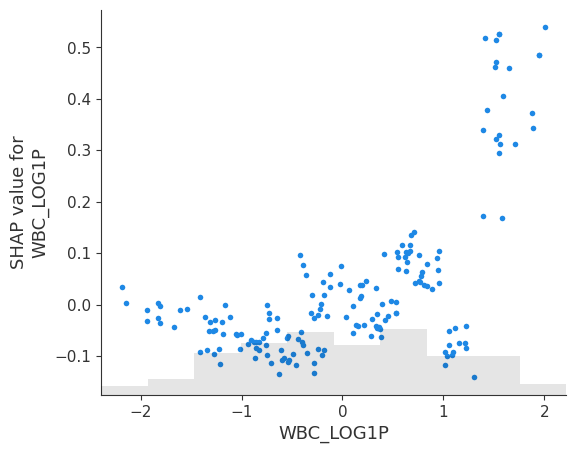

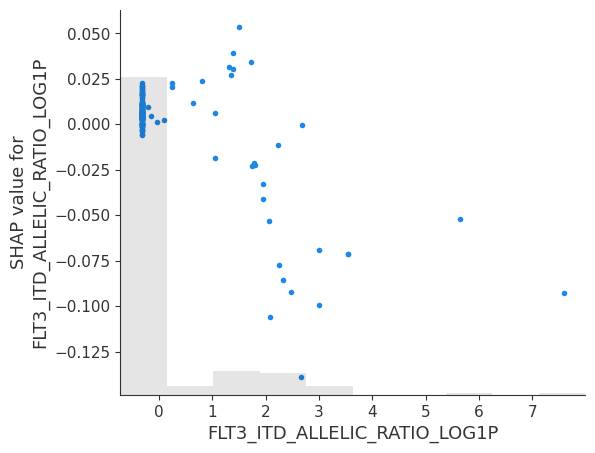

In [15]:
CONTINUOUS_FEATURES = [
    "AGE",
    "BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE",
    "PERIPHERAL_BLASTS_PERCENTAGE",
    "WBC_LOG1P",
    "FLT3_ITD_ALLELIC_RATIO_LOG1P"
]

for feature in CONTINUOUS_FEATURES:

    if feature in FEATURE_COLS:

        shap.plots.scatter(
            shap_values_val[:, feature]
        )

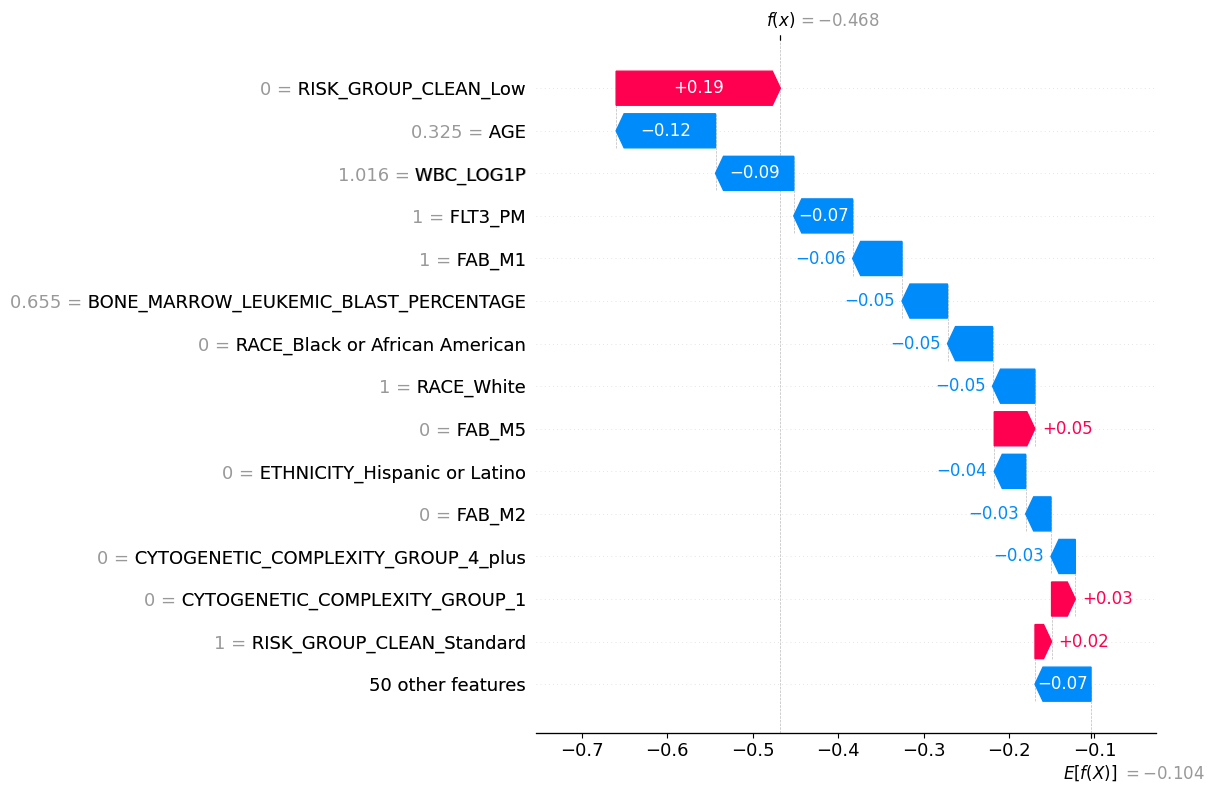

In [16]:
PATIENT_INDEX = 0

shap.plots.waterfall(
    shap_values_val[PATIENT_INDEX],
    max_display=15
)

In [17]:
TOP_K_VALUES = [
    1,
    3,
    5,
    10,
    15
]

N_REPEATS = 30
RANDOM_SEED = 42

In [18]:
ranked_features = (
    shap_importance_val["Feature"]
    .tolist()
)

In [19]:
rng = np.random.default_rng(
    RANDOM_SEED
)

faithfulness_results = []

baseline_cindex = val_cindex

for k in TOP_K_VALUES:

    selected_features = ranked_features[:k]

    repeated_cindices = []

    for repeat in range(N_REPEATS):

        X_permuted = X_val.copy()

        for feature in selected_features:

            X_permuted[feature] = rng.permutation(
                X_permuted[feature].values
            )

        dpermuted = xgb.DMatrix(
            X_permuted,
            feature_names=FEATURE_COLS
        )

        permuted_risk = xgb_model.predict(
            dpermuted,
            iteration_range=(
                0,
                BEST_ITERATION
            )
        )

        cindex = calculate_cindex(
            events_val,
            durations_val,
            permuted_risk
        )

        repeated_cindices.append(
            cindex
        )

    mean_cindex = np.mean(
        repeated_cindices
    )

    sd_cindex = np.std(
        repeated_cindices
    )

    cindex_drop = (
        baseline_cindex
        - mean_cindex
    )

    faithfulness_results.append({
        "Top_K_Features_Permuted": k,
        "C_Index_Mean": mean_cindex,
        "C_Index_SD": sd_cindex,
        "C_Index_Drop": cindex_drop
    })

In [20]:
faithfulness_df = pd.DataFrame(
    faithfulness_results
)

baseline_row = pd.DataFrame({
    "Top_K_Features_Permuted": [0],
    "C_Index_Mean": [baseline_cindex],
    "C_Index_SD": [0.0],
    "C_Index_Drop": [0.0]
})

faithfulness_df = pd.concat(
    [
        baseline_row,
        faithfulness_df
    ],
    ignore_index=True
)

display(
    faithfulness_df.round(3)
)

,Top_K_Features_Permuted,C_Index_Mean,C_Index_SD,C_Index_Drop
0,0,0.692,0.000,0.000
1,1,0.613,0.020,0.079
2,3,0.577,0.025,0.116
3,5,0.535,0.026,0.158
4,10,0.539,0.032,0.154
5,15,0.527,0.035,0.165


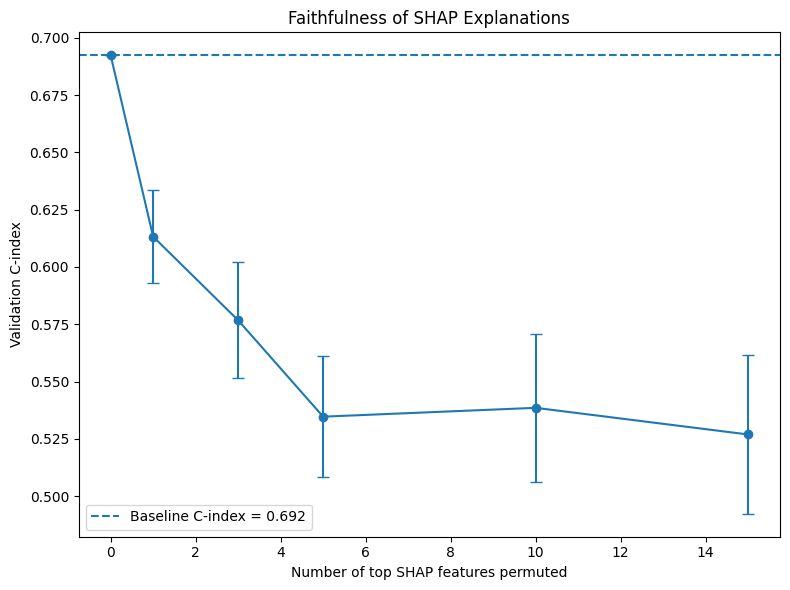

In [21]:
plt.figure(figsize=(8, 6))

plt.errorbar(
    faithfulness_df[
        "Top_K_Features_Permuted"
    ],
    faithfulness_df[
        "C_Index_Mean"
    ],
    yerr=faithfulness_df[
        "C_Index_SD"
    ],
    marker="o",
    capsize=4
)

plt.axhline(
    baseline_cindex,
    linestyle="--",
    label=(
        f"Baseline C-index = "
        f"{baseline_cindex:.3f}"
    )
)

plt.xlabel(
    "Number of top SHAP features permuted"
)

plt.ylabel(
    "Validation C-index"
)

plt.title(
    "Faithfulness of SHAP Explanations"
)

plt.legend()
plt.tight_layout()

plt.show()

In [22]:
shap_values_test = explainer(
    X_test
)

mean_abs_shap_test = np.abs(
    shap_values_test.values
).mean(axis=0)

shap_importance_test = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Mean_Abs_SHAP": mean_abs_shap_test
})

shap_importance_test = (
    shap_importance_test
    .sort_values(
        "Mean_Abs_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    shap_importance_test.head(20)
)

,Feature,Mean_Abs_SHAP
0,RISK_GROUP_CLEAN_Low,0.349208
1,AGE,0.119076
2,PERIPHERAL_BLASTS_PERCENTAGE,0.100307
3,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,0.100066
4,WBC_LOG1P,0.088059
5,RACE_Black or African American,0.085339
6,RACE_White,0.077227
7,ETHNICITY_Hispanic or Latino,0.067307
8,FAB_M5,0.064074
9,PRIMARY_CYTOGENETIC_CODE_Other,0.041790


In [23]:
comparison_df = (
    shap_importance_val
    .rename(
        columns={
            "Mean_Abs_SHAP":
                "Validation_SHAP"
        }
    )
    .merge(
        shap_importance_test.rename(
            columns={
                "Mean_Abs_SHAP":
                    "Test_SHAP"
            }
        ),
        on="Feature"
    )
)

spearman_rho, spearman_p = (
    spearmanr(
        comparison_df[
            "Validation_SHAP"
        ],
        comparison_df[
            "Test_SHAP"
        ]
    )
)

print(
    "Spearman correlation:",
    round(spearman_rho, 3)
)

print(
    "p-value:",
    spearman_p
)

Spearman correlation: 0.996
p-value: 7.586352257005765e-68


In [24]:
TOP_K = 10

val_top10 = set(
    shap_importance_val
    .head(TOP_K)["Feature"]
)

test_top10 = set(
    shap_importance_test
    .head(TOP_K)["Feature"]
)

common_features = (
    val_top10 &
    test_top10
)

union_features = (
    val_top10 |
    test_top10
)

jaccard = (
    len(common_features)
    /
    len(union_features)
)

print(
    "Common features:"
)

for feature in common_features:
    print("-", feature)

print(
    f"\nTop-10 overlap: "
    f"{len(common_features)}/{TOP_K}"
)

print(
    f"Jaccard similarity: "
    f"{jaccard:.3f}"
)

Common features:
- WBC_LOG1P
- BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE
- PRIMARY_CYTOGENETIC_CODE_Other
- PERIPHERAL_BLASTS_PERCENTAGE
- ETHNICITY_Hispanic or Latino
- RACE_White
- FAB_M5
- RACE_Black or African American
- RISK_GROUP_CLEAN_Low
- AGE

Top-10 overlap: 10/10
Jaccard similarity: 1.000
